#  **Unstructured - PDF RAG** 

## **학습 목표**

- **Unstructured 라이브러리**를 활용한 PDF 문서 파싱 기법 이해
- **10-K 보고서 구조**를 활용한 목차 기반 섹션 분할 기법 습득
- **ParentDocumentRetriever**와 **MultiVectorRetriever**의 차이점과 활용 방법 이해
- **요약 기반 검색** 시스템 구현을 통한 RAG 성능 개선 방법 학습

## **사전 준비**

### 필수 패키지
- `langchain-unstructured`: Unstructured 문서 파서
- `langchain-openai`: OpenAI 모델 및 임베딩
- `langchain-chroma`: ChromaDB 벡터 스토어
- `tiktoken`: OpenAI 토크나이저
- `unstructured[pdf]`: PDF 파싱 기능

### 데이터 파일 다운로드
- **파일명**: `tsla-20241231-gen.pdf`
- **파일 위치**: `data/` 폴더에 저장
- **다운로드 출처**: [Tesla Investor Relations - Quarterly Disclosure](https://ir.tesla.com/#quarterly-disclosure)

---

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [3]:
import logging

# 로깅 레벨 설정 
logging.getLogger('pdfminer').setLevel(logging.ERROR)
logging.getLogger('unstructured').setLevel(logging.ERROR)

---

## **테슬라 10-K 리포트 PDF 기반 RAG 시스템 구축 (Unstructured & Langchain)**

- **테슬라 10-K 보고서** PDF를 `unstructured` 라이브러리로 파싱

- **Langchain**과 **ChromaDB**를 활용한 RAG 시스템 구축

- PDF 문서 기반 **지능형 질의응답** 시스템 구현 프로젝트

### 1. **문서 로드**

- **테슬라 10-K 보고서** PDF 파일을 **인터넷에서 다운로드**

- **SEC EDGAR 웹사이트** 또는 **테슬라 IR 페이지**에서 다운로드 가능

- 출처: https://ir.tesla.com/#quarterly-disclosure

In [4]:
from langchain_community.document_loaders import PyPDFLoader

# PDF 파일 경로 지정
file_path = "data/tsla-20241231-gen.pdf"

# PyPDFLoader 초기화
loader = PyPDFLoader(file_path)

# PDF 문서 로드
pypdf_docs = loader.load()

# 로드된 문서 개수 확인
print(len(pypdf_docs)) 

144


In [5]:
# 첫 번째 페이지의 내용 출력
print(f"{pypdf_docs[0].page_content}\n")
print("-" * 100)

# 페이지 메타데이터 확인 
pprint(pypdf_docs[0].metadata)

UNITED	STATES
SECURITIES	AND	EXCHANGE	COMMISSION
Washington,	D.C.	20549
FORM	
10-K
(Mark	One)
x
ANNUAL	REPORT	PURSUANT	TO	SECTION	13	OR	15(d)	OF	THE	SECURITIES	EXCHANGE	ACT	OF	1934
For	the	fiscal	year	ended	
December	31
,	2024
OR
o
TRANSITION	REPORT	PURSUANT	TO	SECTION	13	OR	15(d)	OF	THE	SECURITIES	EXCHANGE	ACT	OF	1934
For	the	transition	period	from	_________	to	_________
Commission	File	Number:	
001-34756
Tesla,	Inc.
(Exact	name	of	registrant	as	specified	in	its	charter)
Texas
91-2197729
(State	or	other	jurisdiction	of
incorporation	or	organization)
(I.R.S.	Employer
Identification	No.)
1	Tesla	Road
Austin
,	
Texas
78725
(Address	of	principal	executive	offices)
(Zip	Code)
(
512
)	
516-8177
(Registrant’s	telephone	number,	including	area	code)
Securities	registered	pursuant	to	Section	12(b)	of	the	Act:
Title	of	each	class
Trading	Symbol(s)
Name	of	each	exchange	on	which	registered
Common	stock
TSLA
The	Nasdaq	Global	Select	Market
Securities	registered	pursuant	to	Section	12(g)	of	the	Act

### 2. **문서 파싱 (Unstructured)**

- **Unstructured 라이브러리**를 사용하여 **PDF 문서 파싱** 및 텍스트 추출을 수행

`(1) 문서 로드`

- LangChain에서 제공하는 UnstructuredLoader 사용   

In [6]:
# 추출한 이미지 저장 폴더 
image_folder = "data/images/tesla_10k"
os.makedirs(image_folder, exist_ok=True)

In [7]:
from langchain_unstructured import UnstructuredLoader
from unstructured.cleaners.core import (
    clean_extra_whitespace,
    replace_unicode_quotes,
    clean_non_ascii_chars,
    group_broken_paragraphs
)

# 로더 생성
# 주의: CPU 실행 시간이 20 ~ 30분 이상 소요될 수 있습니다 (문서 크기에 따라 다름)
loader = UnstructuredLoader(

    # PDF 파일 경로
    file_path,             

    # 파티셔닝 전략 설정
    strategy="hi_res",                         
    infer_table_structure=True,         
    languages=["eng"],           
    
    # 이미지 추출 설정
    extract_images_in_pdf=True,         
    extract_image_block_types=["Image", "Table"],
    extract_image_block_output_dir=image_folder,  

    # 후처리 설정
    post_processors=[
        clean_extra_whitespace,  # 불필요한 공백 제거
        replace_unicode_quotes,  # 유니코드 따옴표 제거
        clean_non_ascii_chars,   # 비 ASCII 문자 제거
        group_broken_paragraphs,  # 줄바꿈으로 분리된 문단 결합
        ], 
)


# 문서 출력
docs = []
for doc in loader.lazy_load():
    docs.append(doc)

# 문서 개수 확인
print(len(docs))

INFO: pikepdf C++ to Python logger bridge initialized
INFO: HTTP Request: HEAD https://huggingface.co/unstructuredio/yolo_x_layout/resolve/main/yolox_l0.05.onnx "HTTP/1.1 302 Found"
INFO: Reading PDF for file: data/tsla-20241231-gen.pdf ...


KeyboardInterrupt: 

In [ ]:
# 문서 출력
for doc in docs[:5]:
    pprint(doc.page_content)
    print("-" * 100)
    pprint(doc.metadata)
    print("=" * 100)
    print()

In [ ]:
# 첫 번째 문서의 내용 출력
pprint(docs[0].page_content)

In [ ]:
# 메타데이터 확인
pprint(docs[0].metadata)

In [ ]:
# 문서 객체를 pickle로 저장
import pickle
with open("data/tesla_10k.pkl", "wb") as f:
    pickle.dump(docs, f)

In [12]:
from langchain_core.documents import Document
import pickle
# pickle로 저장된 문서 객체 로드
with open("ref_data/tesla_10k.pkl", "rb") as f:
    pickled_docs = pickle.load(f)

# 문서 개수 확인
print(len(pickled_docs))

# 첫 번째 문서의 내용 출력
print(f"{pickled_docs[0].page_content}\n")

print("-" * 100)

# 첫 번째 문서의 메타데이터 확인
pprint(pickled_docs[0].metadata)

2580
UNITED STATES SECURITIES AND EXCHANGE COMMISSION

----------------------------------------------------------------------------------------------------
{'category': 'Title',
 'coordinates': {'layout_height': 3850,
                 'layout_width': 2975,
                 'points': ((np.float64(685.1292114257812),
                             np.float64(271.9077453613281)),
                            (np.float64(685.1292114257812),
                             np.float64(427.4071960449219)),
                            (np.float64(2287.177978515625),
                             np.float64(427.4071960449219)),
                            (np.float64(2287.177978515625),
                             np.float64(271.9077453613281))),
                 'system': 'PixelSpace'},
 'detection_class_prob': 0.519172191619873,
 'element_id': 'd43322fb3697e399ffd81e7a3f4f6495',
 'file_directory': 'data',
 'filename': 'tsla-20241231-gen.pdf',
 'filetype': 'application/pdf',
 'is_extracted': 'true',

`(2) 표 데이터 변환`

- 테이블 형식의 데이터를 마크다운 텍스트로 변환하여 처리
- `hi_res` 결과의 `text_as_html`이 빈 표인 경우에는 추출된 `page_content`를 대신 사용하여 텍스트 유실을 방지

In [13]:
docs = pickled_docs

In [14]:
# 문서 구성 요소의 유형 확인
category_counts = {}

for doc in docs:
    category = doc.metadata["category"]
    if category in category_counts:
        category_counts[category] += 1
    else:
        category_counts[category] = 1

# 카테고리별 문서 개수 출력
pprint(category_counts)

{'Footer': 119,
 'Header': 34,
 'Image': 4,
 'ListItem': 89,
 'NarrativeText': 689,
 'Table': 91,
 'Title': 395,
 'UncategorizedText': 1159}


In [15]:
# 카테고리별로 문서 재정리
from io import StringIO

new_docs = []
table_fallbacks = 0

for doc in docs:
    category = doc.metadata.get("category")

    # Table 카테고리의 문서를 마크다운 형식으로 변환
    if category == "Table":
        html = doc.metadata.get("text_as_html") or ""

        try:
            tables = pd.read_html(StringIO(html)) if html else []
        except (ValueError, TypeError):
            tables = []

        if tables:
            markdown = "\n\n".join(
                table.to_markdown(index=False) for table in tables
            )
        else:
            # hi_res가 빈 HTML 표를 반환하면 추출 텍스트를 대신 보존
            markdown = doc.page_content.strip()
            table_fallbacks += 1

        if markdown:
            new_docs.append(
                Document(page_content=markdown, metadata=dict(doc.metadata))
            )

    # Header, Footer, Image 카테고리의 문서는 제외
    elif category in ["Header", "Footer", "Image"]:
        continue

    # 나머지 문서는 그대로 추가
    else:
        new_docs.append(doc)

print(f"변환된 문서: {len(new_docs)}개")
print(f"HTML 표 fallback: {table_fallbacks}개")

변환된 문서: 2423개
HTML 표 fallback: 1개


### 3. **텍스트 청킹 (Langchain)**

- **텍스트 청킹**은 대규모 텍스트를 의미 있는 **작은 단위로 분할**하는 기술

- 주요 목적은 **벡터 데이터베이스 저장 및 검색 효율성 향상**

`(1) 적정 청크 크기`

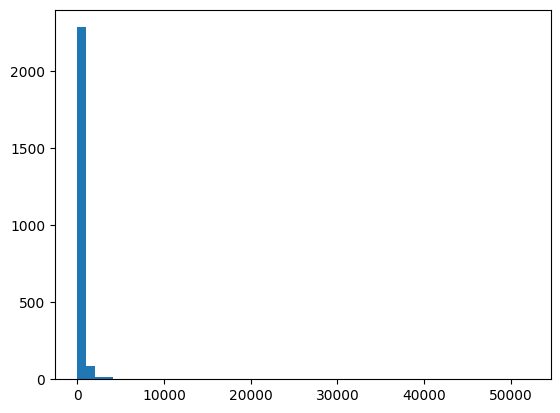

In [16]:
# 각 문서의 page_content 길이 확인

doc_lengths = [len(doc.page_content) for doc in new_docs]

# 문서 길이 시각화
import matplotlib.pyplot as plt

plt.hist(doc_lengths, bins=50)
plt.show()

In [17]:
# 문서 타입별 개수 확인
category_counts = {}

for doc in new_docs:
    category = doc.metadata["category"]
    if category in category_counts:
        category_counts[category] += 1
    else:
        category_counts[category] = 1

# 카테고리별 문서 개수 출력
pprint(category_counts)

{'ListItem': 89,
 'NarrativeText': 689,
 'Table': 91,
 'Title': 395,
 'UncategorizedText': 1159}


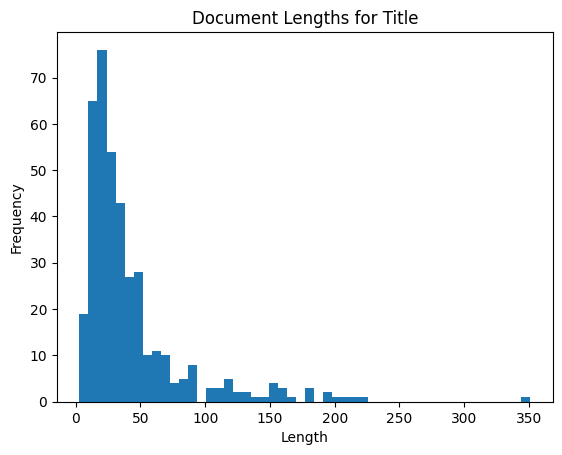

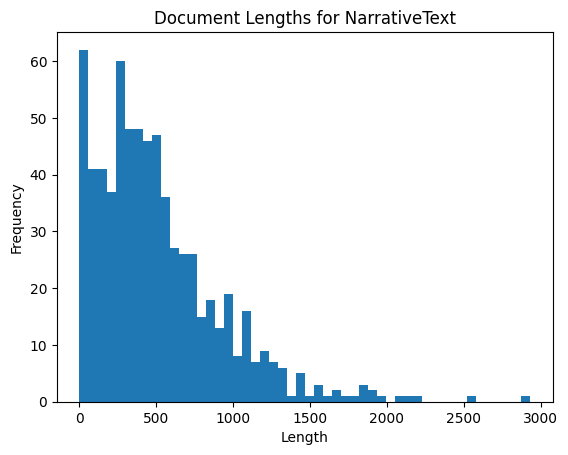

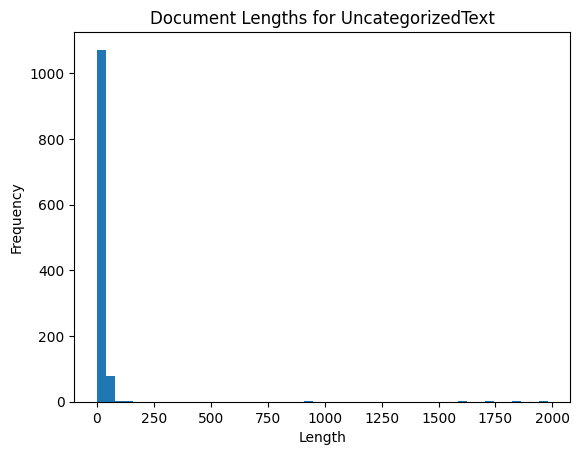

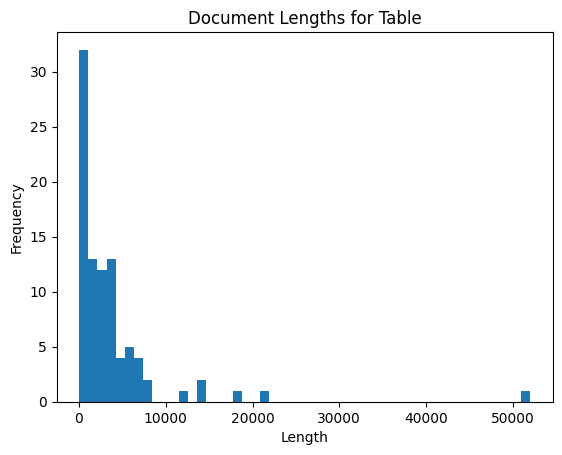

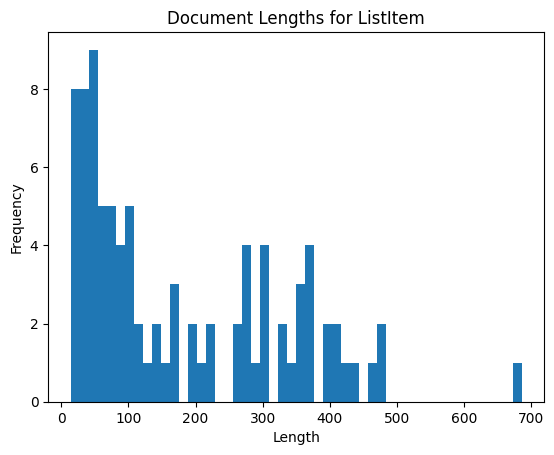

In [18]:
# 문서 타입별로 문서 길이 확인
category_lengths = {}
for doc in new_docs:
    category = doc.metadata["category"]
    if category not in category_lengths:
        category_lengths[category] = []
    category_lengths[category].append(len(doc.page_content))

# 카테고리별 문서 길이 시각화
for category, lengths in category_lengths.items():
    plt.hist(lengths, bins=50)
    plt.title(f"Document Lengths for {category}")
    plt.xlabel("Length")
    plt.ylabel("Frequency")
    plt.show()

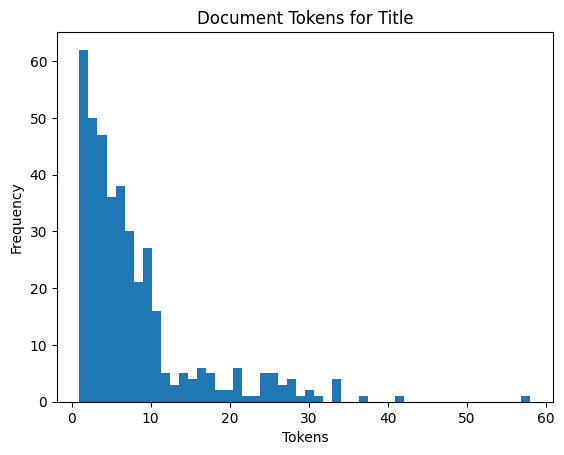

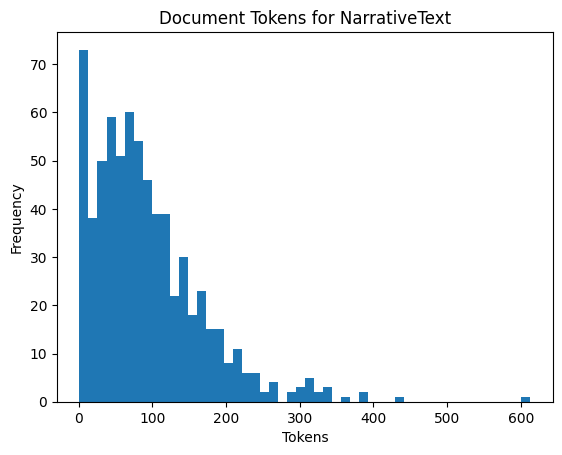

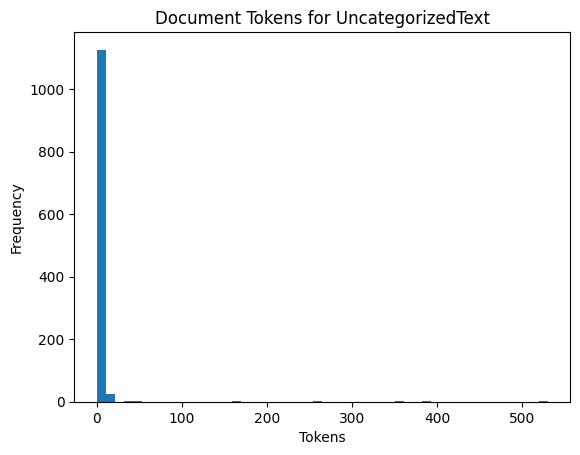

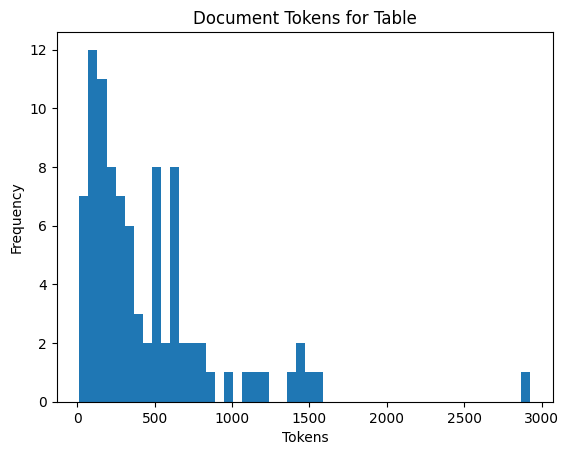

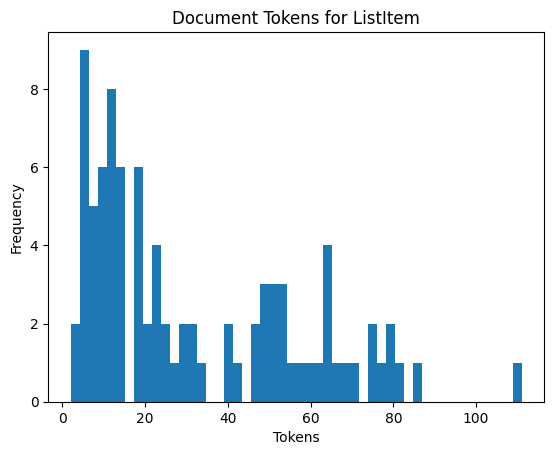

In [21]:
# 문서 타입별 토큰 수 확인 (tiktoken tokenizer 사용)

import tiktoken

# tiktoken tokenizer 초기화
tokenizer = tiktoken.get_encoding("o200k_base")

# 문서 타입별로 토큰 수 확인
category_tokens = {}
for doc in new_docs:
    category = doc.metadata["category"]
    if category not in category_tokens:
        category_tokens[category] = []
    category_tokens[category].append(len(tokenizer.encode(doc.page_content)))
    
# 카테고리별 토큰 수 시각화
for category, tokens in category_tokens.items():
    plt.hist(tokens, bins=50)
    plt.title(f"Document Tokens for {category}")
    plt.xlabel("Tokens")
    plt.ylabel("Frequency")
    plt.show()

`(2) 목차 항목 추출`

- **10-K 보고서 구조**: SEC 규정에 따라 표준화된 항목(Item)으로 구성
- **주요 섹션**: Business, Risk Factors, Legal Proceedings, Financial Statements 등
- **목차 기반 분할 목적**: 보고서의 논리적 구조를 유지하며 섹션별 검색 정확도 향상

In [20]:
# 3페이지(page_number) 목차 항목을 기준으로 그룹화 

toc_items = [ doc.page_content for doc in new_docs if doc.metadata["page_number"] == 3]
toc_items

['TESLA, INC.',
 'ANNUAL REPORT ON FORM 10-K FOR THE YEAR ENDED DECEMBER 31, 2024',
 'INDEX',
 'PART I.',
 'Item 1. Business',
 'Item 1A. Risk Factors',
 'Item 1B. Unresolved Staff Comments',
 'Item 1C. Cybersecurity',
 'Item 2. Properties',
 'Item 3. Legal Proceedings',
 'Item 4. Mine Safety Disclosures',
 "| Item 5.   | Market for Registrant's Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities   |\n|:----------|:---------------------------------------------------------------------------------------------------------------|\n| Item 6.   | [Reserved                                                                                                      |\n| Item 7.   | Management's Discussion and Analysis of Financial Condition and Results of Operations                          |\n| Item 7A.  | Quantitative and Qualitative Disclosures about Market Risk                                                     |\n| Item 8.   | Financial Statements and Supplementa

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

# 목차 항목 모델 정의
class Item(BaseModel):
    number: str = Field(description="목차 항목 번호 (예: 1, 1A, 1B, 2, 3 등)")
    title: str = Field(description="목차 항목 제목")

class Section(BaseModel):
    section: str = Field(description="목차 항목 그룹")
    items: list[Item] = Field(description="목차 항목 리스트")


# 목차 텍스트에서 항목을 추출하기 위한 프롬프트
TOC_PROMPT = """
You are a helpful assistant.
The user will provide you with a list of items.

Your task is to group these items into sections based on their content.

Please provide the output in JSON format.
The JSON should contain the following fields:
- section: The name of the section
- items: A list of items that belong to this section

The items are as follows:
{items}
"""

# 프롬프트 템플릿 생성
toc_prompt_template = PromptTemplate(
    input_variables=["items"],
    template=TOC_PROMPT
)

# LLM 정의 
# 주의: 실행 시간이 10-30초 정도 소요될 수 있습니다 (API 응답 시간에 따라 다름)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_structured = llm.with_structured_output(Section)

# LCEL 체인 
toc_chain = toc_prompt_template | llm_structured

# 목차 항목을 기준으로 그룹화
toc_section = toc_chain.invoke({"items": "\n\n".join(toc_items)})

# 그룹화된 목차 항목 확인
pprint(toc_section)


Section(section='Annual Report', items=[Item(number='1', title='Business'), Item(number='1A', title='Risk Factors'), Item(number='1B', title='Unresolved Staff Comments'), Item(number='1C', title='Cybersecurity'), Item(number='2', title='Properties'), Item(number='3', title='Legal Proceedings'), Item(number='4', title='Mine Safety Disclosures'), Item(number='5', title="Market for Registrant's Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities"), Item(number='6', title='[Reserved]'), Item(number='7', title="Management's Discussion and Analysis of Financial Condition and Results of Operations"), Item(number='7A', title='Quantitative and Qualitative Disclosures about Market Risk'), Item(number='8', title='Financial Statements and Supplementary Data'), Item(number='9', title='Changes in and Disagreements with Accountants on Accounting and Financial Disclosure'), Item(number='9A', title='Controls and Procedures'), Item(number='9B', title='Other Information')

In [23]:
for item in toc_section.items:
    print(f"{item.number}: {item.title}")

1: Business
1A: Risk Factors
1B: Unresolved Staff Comments
1C: Cybersecurity
2: Properties
3: Legal Proceedings
4: Mine Safety Disclosures
5: Market for Registrant's Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities
6: [Reserved]
7: Management's Discussion and Analysis of Financial Condition and Results of Operations
7A: Quantitative and Qualitative Disclosures about Market Risk
8: Financial Statements and Supplementary Data
9: Changes in and Disagreements with Accountants on Accounting and Financial Disclosure
9A: Controls and Procedures
9B: Other Information
10: Directors, Executive Officers and Corporate Governance
11: Executive Compensation
12: Security Ownership of Certain Beneficial Owners and Management and Related Stockholder Matters
13: Certain Relationships and Related Transactions, and Director Independence
14: Principal Accountant Fees and Services
15: Exhibits and Financial Statement Schedules
16: Form 10-K Summary


In [24]:
# toc_items에 "Item 1.", "Item 1A." 등이 별도 항목으로 존재하므로
# 이를 기준으로 number 매핑
for item in toc_section.items:
    if item.number == '0' and item.title == 'Business':
        item.number = '1'

for item in toc_section.items:
    print(f"{item.number}: {item.title}")


1: Business
1A: Risk Factors
1B: Unresolved Staff Comments
1C: Cybersecurity
2: Properties
3: Legal Proceedings
4: Mine Safety Disclosures
5: Market for Registrant's Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities
6: [Reserved]
7: Management's Discussion and Analysis of Financial Condition and Results of Operations
7A: Quantitative and Qualitative Disclosures about Market Risk
8: Financial Statements and Supplementary Data
9: Changes in and Disagreements with Accountants on Accounting and Financial Disclosure
9A: Controls and Procedures
9B: Other Information
10: Directors, Executive Officers and Corporate Governance
11: Executive Compensation
12: Security Ownership of Certain Beneficial Owners and Management and Related Stockholder Matters
13: Certain Relationships and Related Transactions, and Director Independence
14: Principal Accountant Fees and Services
15: Exhibits and Financial Statement Schedules
16: Form 10-K Summary


In [25]:
import re

def get_item_header_patterns(item_number, item_title):
    """
    정규표현식(Regex)을 사용하여 줄바꿈이나 공백을 허용하는 패턴을 생성합니다.
    """
    # 공백이나 줄바꿈(\s+)을 허용하도록 정규 표현식 생성
    # 예: "item\s+1\.\s+business"
    num = item_number.lower()
    title = item_title.lower()
    
    # 특수문자 이스케이프(title 내에 혹시 모를 괄호 처리 등) 및 공백을 정규식 공백으로 처리
    escaped_title = re.escape(title).replace(r"\ ", r"\s+")
    
    # 1. 일반적인 "ITEM 1. BUSINESS" 패턴 (마침표 유무 및 다중 공백 허용)
    pattern1 = rf"item\s+{num}\.?\s+{escaped_title}"
    
    # 2. 항목 번호만 있는 패턴이 필요한 경우 "item 1."
    # pattern2 = rf"item\s+{num}\." 
    
    return [pattern1]

toc_based_docs = []
current_section = None

for i, doc in enumerate(new_docs):
    new_section_found = False
    
    # 비교를 위해 문서 내용을 소문자로 변환
    content_lower = doc.page_content.lower()
    
    for item in toc_section.items:
        # 정규식 패턴을 가져옵니다
        item_patterns = get_item_header_patterns(item.number, item.title)
        
        # 정규식을 통한 유연한 매치 검색
        matched_pattern = None
        for pattern in item_patterns:
            match = re.search(pattern, content_lower)
            if match:
                current_section = item.title
                new_section_found = True
                matched_pattern = match
                break
                
        if new_section_found:
            break

    # page_content에서 목차 항목 부분부터 추출
    if new_section_found and matched_pattern:
        # 실제 원본 텍스트(대소문자 원래 상태)에서 매칭된 단어의 시작 인덱스를 찾아 자름
        start_index = matched_pattern.start()
        doc.page_content = doc.page_content[start_index:]
    
    # 문서에 섹션 메타데이터 추가
    doc_copy = Document(
        page_content=doc.page_content,
        metadata={
            **doc.metadata,
            "section": current_section if current_section else "Unknown"
        }
    )
    toc_based_docs.append(doc_copy)


# 섹션별 문서 개수 확인
section_counts = {}
for doc in toc_based_docs:
    section = doc.metadata.get("section", "Unknown")
    section_counts[section] = section_counts.get(section, 0) + 1

print("Section distribution:")
for section, count in section_counts.items():
    print(f"{section}: {count} documents")

Section distribution:
Unknown: 55 documents
Business: 164 documents
Risk Factors: 136 documents
Unresolved Staff Comments: 3 documents
Cybersecurity: 14 documents
Properties: 6 documents
Legal Proceedings: 3 documents
Mine Safety Disclosures: 20 documents
Directors, Executive Officers and Corporate Governance: 3 documents
Executive Compensation: 3 documents
Security Ownership of Certain Beneficial Owners and Management and Related Stockholder Matters: 5 documents
Certain Relationships and Related Transactions, and Director Independence: 1 documents
Principal Accountant Fees and Services: 5 documents
Exhibits and Financial Statement Schedules: 724 documents
[Reserved]: 155 documents
Quantitative and Qualitative Disclosures about Market Risk: 5 documents
Financial Statements and Supplementary Data: 1098 documents
Changes in and Disagreements with Accountants on Accounting and Financial Disclosure: 2 documents
Controls and Procedures: 15 documents
Other Information: 6 documents


In [26]:
# 목차 항목의 순서에 따라 섹션 정렬
section_order = {item.title: idx for idx, item in enumerate(toc_section.items)}

# "Unknown" 섹션을 마지막에 추가
section_order["Unknown"] = len(section_order)

# 섹션 순서에 따라 문서 정렬
toc_based_docs_sorted = sorted(
    toc_based_docs, 
    key=lambda x: section_order.get(x.metadata.get("section", "Unknown"), float('inf'))
)

# 섹션별 문서 개수 확인 (정렬된 문서)
section_counts_sorted = {}
for doc in toc_based_docs_sorted:
    section = doc.metadata.get("section", "Unknown")
    section_counts_sorted[section] = section_counts_sorted.get(section, 0) + 1

# 정렬된 섹션 분포 출력
print("\nSorted section distribution:")
for section in sorted(section_counts_sorted.keys(), key=lambda x: section_order.get(x, float('inf'))):
    print(f"{section}: {section_counts_sorted[section]} documents")


Sorted section distribution:
Business: 164 documents
Risk Factors: 136 documents
Unresolved Staff Comments: 3 documents
Cybersecurity: 14 documents
Properties: 6 documents
Legal Proceedings: 3 documents
Mine Safety Disclosures: 20 documents
[Reserved]: 155 documents
Quantitative and Qualitative Disclosures about Market Risk: 5 documents
Financial Statements and Supplementary Data: 1098 documents
Changes in and Disagreements with Accountants on Accounting and Financial Disclosure: 2 documents
Controls and Procedures: 15 documents
Other Information: 6 documents
Directors, Executive Officers and Corporate Governance: 3 documents
Executive Compensation: 3 documents
Security Ownership of Certain Beneficial Owners and Management and Related Stockholder Matters: 5 documents
Certain Relationships and Related Transactions, and Director Independence: 1 documents
Principal Accountant Fees and Services: 5 documents
Exhibits and Financial Statement Schedules: 724 documents
Unknown: 55 documents


In [27]:
# 문서 객체를 pickle로 저장
with open("data/tesla_10k_toc.pkl", "wb") as f:
    pickle.dump(toc_based_docs_sorted, f)

In [28]:
# pickle로 저장된 문서 객체 로드
with open("data/tesla_10k_toc.pkl", "rb") as f:
    toc_based_docs_sorted = pickle.load(f)

# 문서 개수 확인
print(len(toc_based_docs_sorted))

2423


`(3) 섹션별로 결합`

- 보고서 섹션별로 문서 객체를 결합하여 재구조화 

In [29]:
# Unknown 제외 나머지 섹션별로 결합 

section_docs = {}

for doc in toc_based_docs_sorted:
    section = doc.metadata.get("section", "Unknown")
    if section == "Unknown":
        continue
    if section not in section_docs:
        section_docs[section] = []
    section_docs[section].append(doc)

# 섹션별로 문서 결합
section_docs_combined = {}
for section, docs in section_docs.items():
    combined_content = "\n\n".join([doc.page_content for doc in docs])
    combined_metadata = docs[0].metadata
    section_docs_combined[section] = Document(page_content=combined_content, metadata=combined_metadata)


# 결합된 문서 개수 확인
print(len(section_docs_combined))

19


In [30]:
# 문서 저장
with open("data/tesla_10k_sections.pkl", "wb") as f:
    pickle.dump(section_docs_combined, f)

In [31]:
# pickle로 저장된 문서 객체 로드
import pickle
with open("data/tesla_10k_sections.pkl", "rb") as f:
    section_docs_combined = pickle.load(f)

# 문서 개수 확인
print(len(section_docs_combined))

19


In [32]:
section_docs_combined

{'Business': Document(metadata={'source': 'data/tsla-20241231-gen.pdf', 'detection_class_prob': 0.44708868861198425, 'is_extracted': 'true', 'coordinates': {'points': ((np.float64(73.22638702392578), np.float64(729.31787109375)), (np.float64(73.22638702392578), np.float64(774.3724975585938)), (np.float64(544.9050903320312), np.float64(774.3724975585938)), (np.float64(544.9050903320312), np.float64(729.31787109375))), 'system': 'PixelSpace', 'layout_width': 2975, 'layout_height': 3850}, 'last_modified': '2026-08-04T01:18:17', 'filetype': 'application/pdf', 'languages': ['eng'], 'page_number': 3, 'file_directory': 'data', 'filename': 'tsla-20241231-gen.pdf', 'parent_id': '72acbb81c71f313dadda27ffad5e0fa3', 'category': 'ListItem', 'element_id': '3944dd7496a9eb69b8c8126d7432983b', 'section': 'Business'}, page_content="Item 1. Business\n\nITEM 1. BUSINESS\n\nOverview\n\nWe design, develop, manufacture, sell and lease high-performance fully electric vehicles and energy generation and storage

In [33]:
# 첫 번째 문서의 내용 출력
print(f"{section_docs_combined['Business'].page_content}\n")

# 첫 번째 문서의 메타데이터 확인
pprint(section_docs_combined['Business'].metadata)

Item 1. Business

ITEM 1. BUSINESS

Overview

We design, develop, manufacture, sell and lease high-performance fully electric vehicles and energy generation and storage systems, and offer services related to our products. We generally sell our products directly to customers, and continue to grow our customer-facing infrastructure through a global network of vehicle showrooms and service centers, Mobile Service, body shops, Supercharger stations and Destination Chargers to accelerate the widespread adoption of our products. We emphasize performance, attractive styling and the safety of our users and workforce in the design and manufacture of our products and are continuing to develop full self-driving technology for improved safety. We also strive to lower the cost of ownership for our customers through continuous efforts to reduce manufacturing costs and by offering financial and other services tailored to our products.

Our mission is to accelerate the worlds transition to sustainable

### 4. **Parent Document Retriever**

- 문서 검색 시 **작은 단위 분할**과 **문맥 유지** 사이의 균형이 중요함

- 작은 단위로 분할하면 **임베딩의 정확도**가 높아지나 문맥이 손실될 수 있음

- **ParentDocumentRetriever**는 작은 청크로 저장하고 검색 시 상위 문서를 반환하여 두 가지 목표를 달성함

- 효과적인 문서 검색을 위해 청크 크기와 문맥 보존 사이의 최적점을 찾는 것이 핵심

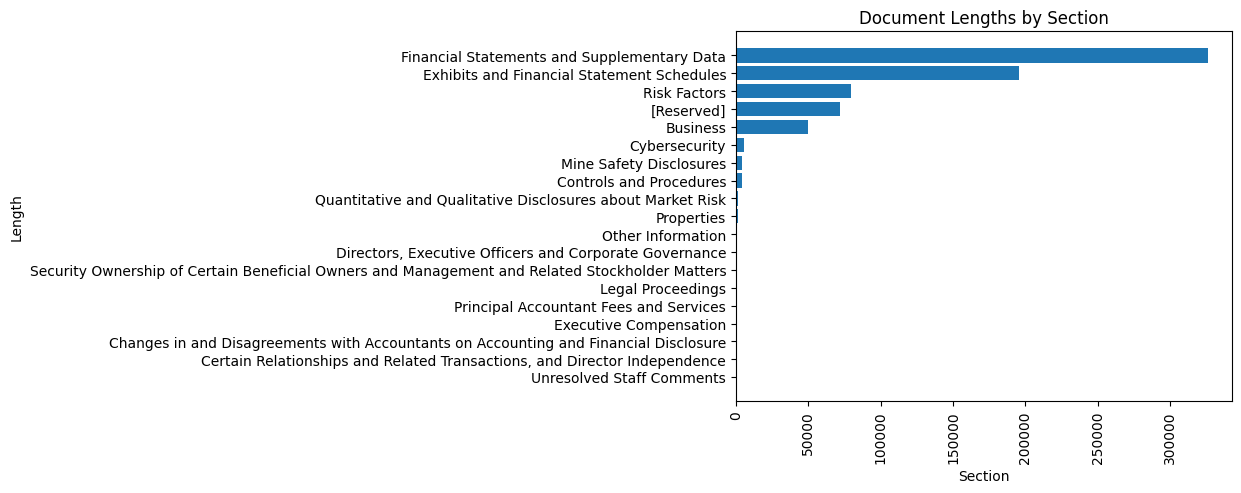

In [34]:
# 각 섹션별로 문서 길이 확인
section_lengths = {section: len(doc.page_content) for section, doc in section_docs_combined.items()}

# 길이 순서로 정렬
section_lengths = dict(sorted(section_lengths.items(), key=lambda item: item[1]))

# 섹션별 문서 길이 시각화
plt.barh(section_lengths.keys(), section_lengths.values())
plt.xticks(rotation=90)
plt.xlabel("Section")
plt.ylabel("Length")
plt.title("Document Lengths by Section")
plt.show()

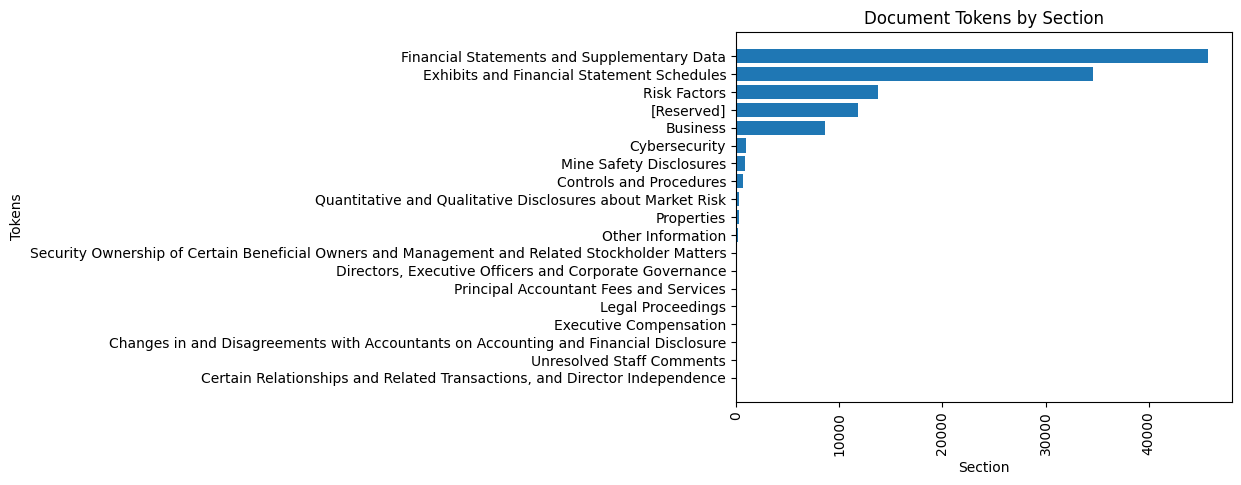

In [35]:
import tiktoken

# tiktoken tokenizer 초기화
tokenizer = tiktoken.get_encoding("cl100k_base")

# 각 섹션별로 토큰 수 확인
section_tokens = {section: len(tokenizer.encode(doc.page_content)) for section, doc in section_docs_combined.items()}

# 길이 순서로 정렬
section_tokens = dict(sorted(section_tokens.items(), key=lambda item: item[1]))

# 섹션별 토큰 수 시각화
plt.barh(section_tokens.keys(), section_tokens.values())
plt.xticks(rotation=90)
plt.xlabel("Section")
plt.ylabel("Tokens")
plt.title("Document Tokens by Section")
plt.show()

In [36]:
# 첫 번째 섹션의 메타데이터 확인
pprint(section_docs_combined['Business'].metadata)

{'category': 'ListItem',
 'coordinates': {'layout_height': 3850,
                 'layout_width': 2975,
                 'points': ((np.float64(73.22638702392578),
                             np.float64(729.31787109375)),
                            (np.float64(73.22638702392578),
                             np.float64(774.3724975585938)),
                            (np.float64(544.9050903320312),
                             np.float64(774.3724975585938)),
                            (np.float64(544.9050903320312),
                             np.float64(729.31787109375))),
                 'system': 'PixelSpace'},
 'detection_class_prob': 0.44708868861198425,
 'element_id': '3944dd7496a9eb69b8c8126d7432983b',
 'file_directory': 'data',
 'filename': 'tsla-20241231-gen.pdf',
 'filetype': 'application/pdf',
 'is_extracted': 'true',
 'languages': ['eng'],
 'last_modified': '2026-08-04T01:18:17',
 'page_number': 3,
 'parent_id': '72acbb81c71f313dadda27ffad5e0fa3',
 'section': 'Business

In [38]:
# 토큰 수 기준으로 3000개 이상이면 분할 (섹션 내의 순서 정보를 metadata에 추가)
# 주의: 현재는 문자 수 3000개 기준으로 분할합니다 (토큰 수 아님)
# - len(doc.page_content)는 문자(character) 수를 반환합니다
# - 실제 토큰 기반 분할을 원하면 RecursiveCharacterTextSplitter.from_tiktoken_encoder() 사용을 권장합니다
from langchain_core.documents import Document
import tiktoken


tokenizer = tiktoken.get_encoding("cl100k_base")

section_docs_split = {}

for section, doc in section_docs_combined.items():

    filtered_metadata = {
        'element_id': doc.metadata['element_id'],
        'parent_id': doc.metadata['parent_id'] if 'parent_id' in doc.metadata else None,
        'source': doc.metadata['source'],
        'page_number': doc.metadata['page_number'],   
        'section': section        
    }

    tokens = len(tokenizer.encode(doc.page_content))
    if tokens > 3000:
        # 문서 분할 (문자 수 기준)
        split_docs = []
        for i in range(0, len(doc.page_content), 3000):
            split_doc = Document(
                page_content=doc.page_content[i:i+3000],
                metadata={
                    **filtered_metadata,
                    "order": i // 3000 + 1
                }
            )
            split_docs.append(split_doc)
        section_docs_split[section] = split_docs
    else:
        # 문서 그대로 추가
        doc.metadata = filtered_metadata
        doc.metadata["order"] = 1
        section_docs_split[section] = [doc]


# 분할된 문서 개수 확인
len([doc for docs in section_docs_split.values() for doc in docs])

257

In [39]:
section_docs_split['Business'][0].metadata 

{'element_id': '3944dd7496a9eb69b8c8126d7432983b',
 'parent_id': '72acbb81c71f313dadda27ffad5e0fa3',
 'source': 'data/tsla-20241231-gen.pdf',
 'page_number': 3,
 'section': 'Business',
 'order': 1}

In [40]:
# 문서 객체를 pickle로 저장
with open("data/tesla_10k_sections_split.pkl", "wb") as f:
    pickle.dump(section_docs_split, f)

In [41]:
# pickle로 저장된 문서 객체 로드
with open("data/tesla_10k_sections_split.pkl", "rb") as f:
    section_docs_split = pickle.load(f)

# 문서 개수 확인
print(len([doc for docs in section_docs_split.values() for doc in docs]))

257


In [42]:
from langchain_classic.retrievers import ParentDocumentRetriever
from langchain_classic.storage import LocalFileStore
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
import os
import pickle

# 문서 저장소 경로 설정
storage_path = "./document_store"
os.makedirs(storage_path, exist_ok=True)

# 부모 문서 저장소 클래스 정의
class PickleFileStore(LocalFileStore):
    def mget(self, keys):
        """Get the values for the given keys."""
        return [pickle.loads(v) if v is not None else None 
                for v in super().mget(keys)]

    def mset(self, key_value_pairs):
        """Set the values for the given key-value pairs."""
        serialized_pairs = [
            (k, pickle.dumps(v)) for k, v in key_value_pairs
        ]
        super().mset(serialized_pairs)

# 부모 문서 저장소 초기화
store = PickleFileStore(storage_path)

# 부모 문서용 텍스트 스플리터 (섹션 단위로 큰 청크)
parent_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=2000,
    chunk_overlap=400,
    separators=["\n\n", "\n", " ", ""]
)

# 자식 문서용 텍스트 스플리터 (검색용 작은 청크)
child_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500,
    chunk_overlap=100,
    separators=["\n\n", "\n", " ", ""]
)

# 벡터 스토어 초기화
vectorstore = Chroma(
    collection_name="tesla_10k_sections",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db"
)

# ParentDocumentRetriever 설정
retriever = ParentDocumentRetriever(
    vectorstore=vectorstore,
    docstore=store,
    child_splitter=child_splitter,
    parent_splitter=parent_splitter,
)

# 문서 추가
retriever.add_documents(
    [
        doc
        for docs in section_docs_split.values()
        for doc in docs
    ]
)

In [43]:
# 저장된 문서 수 확인 
print(f"Total documents in vectorstore: {vectorstore._collection.count()}")

# 로컬 저장소 문서 수 확인
all_keys = list(store.yield_keys())
print(f"Total documents in store: {len(all_keys)}")


Total documents in vectorstore: 1031
Total documents in store: 333


In [44]:
# Test 검색
query = "What are the main risk factors?"
retrieved_docs = retriever.invoke(query)

print(f"Retrieved {len(retrieved_docs)} documents")
for doc in retrieved_docs:
    print(doc.page_content[:500])
    print("-" * 100)

Retrieved 4 documents
Item 1A. Risk Factors

ITEM 1A. RISK FACTORS

You should carefully consider the risks described below together with the other information set forth in this report, which could materially affect our business, financial condition and future results. The risks described below are not the only risks facing our company. Risks and uncertainties not currently known to us or that we currently deem to be immaterial also may materially adversely affect our business, financial condition and operating resul
----------------------------------------------------------------------------------------------------
ble domestically or have local suppliers, may provide a greater benefit to our competitors, which could negatively impact our profitability. Many of our competitors have significantly more or better-established resources than we do to devote to the design, development, manufacturing, distribution, promotion, sale and support of their products. Increased competition could re

In [45]:
# 벡터 스토어 로드
vectorstore = Chroma(
    collection_name="tesla_10k_sections",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db"
)

# 로컬 파일 저장소 로드
storage_path = "./document_store"
store = PickleFileStore(storage_path)

# ParentDocumentRetriever 설정
retriever = ParentDocumentRetriever(
    vectorstore=vectorstore,
    docstore=store,
    child_splitter=child_splitter,
    parent_splitter=parent_splitter,
)

# Test 검색
query = "What are the main risk factors?"

retrieved_docs = retriever.invoke(query)
print(f"Retrieved {len(retrieved_docs)} documents")

for doc in retrieved_docs:
    print(doc.page_content[:500])
    print("-" * 100)

Retrieved 4 documents
Item 1A. Risk Factors

ITEM 1A. RISK FACTORS

You should carefully consider the risks described below together with the other information set forth in this report, which could materially affect our business, financial condition and future results. The risks described below are not the only risks facing our company. Risks and uncertainties not currently known to us or that we currently deem to be immaterial also may materially adversely affect our business, financial condition and operating resul
----------------------------------------------------------------------------------------------------
ble domestically or have local suppliers, may provide a greater benefit to our competitors, which could negatively impact our profitability. Many of our competitors have significantly more or better-established resources than we do to devote to the design, development, manufacturing, distribution, promotion, sale and support of their products. Increased competition could re

In [46]:
# 다른 쿼리 

query = "Where is Tesla's headquarters located?"

retrieved_docs = retriever.invoke(query)
print(f"Retrieved {len(retrieved_docs)} documents")

for doc in retrieved_docs:
    print(doc.page_content[:500])
    print("-" * 100)

Retrieved 2 documents
| Netherlands  |
| Tesla Finance LLC                                      | Delaware     |
| Tesla Financial Leasing (China) Co., Ltd.              | China        |
| Tesla Financial Services GmbH                          | Germany      |
| Tesla Financial Services Holdings B.V.                 | Netherlands  |
| Tesla Financial Services Limited                       | United King: |
| Tesla Fleet Operations LLC                             | Texas        |
| Tesla France S.a r.l.                
----------------------------------------------------------------------------------------------------
----------------------------------|:----------------------|
| Tesla Motors Iceland ehf.                       | Iceland               |
| Tesla Motors Ireland Limited                    | Ireland               |
| Tesla Motors Israel Ltd.                        | Israel                |
| Tesla Motors Japan GK                           | Japan                 |
| Tesla Moto

In [ ]:
# vectorstore.delete_collection()

### 5. **다중 벡터 기반 검색(Multi Vector Retrieval)**

- **Multi-Vector Retriever**는 문서를 **여러 벡터**로 분할하여 저장하고 검색하는 시스템
    1. 벡터 저장소(Vectorstore): 임베딩 저장
    2. 문서 저장소(Docstore): 원본 문서 저장

- 예제: **요약 기반 검색 시스템** 구현

    - 각 섹션의 간결한 요약문을 생성하여 벡터 저장소에 보관하고 유사도 검색에 활용함
    - **영구 저장소**는 PickleFileStore와 Chroma를 사용하여 문서와 벡터 데이터를 세션 간 유지함
    - **검색 과정**은 요약문으로 의미론적 매칭을 수행하고 전체 원본 문서를 반환하여 완전한 문맥을 제공함
    - **RAG 파이프라인**은 ChatGPT를 활용하여 요약 생성과 최종 답변을 처리하며 명확한 응답 형식을 제공함

In [47]:
from langchain_classic.retrievers import MultiVectorRetriever
from langchain_classic.storage import LocalFileStore
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import os
import pickle

# 로컬 파일 저장소 클래스 정의
class PickleFileStore(LocalFileStore):
    def mget(self, keys):
        return [pickle.loads(v) if v is not None else None 
                for v in super().mget(keys)]

    def mset(self, key_value_pairs):
        serialized_pairs = [(k, pickle.dumps(v)) for k, v in key_value_pairs]
        super().mset(serialized_pairs)

# 저장소 디렉토리 생성
os.makedirs("./summary_store", exist_ok=True)
os.makedirs("./chroma_db", exist_ok=True)

# 로컬 파일 저장소 초기화
doc_store = PickleFileStore("./summary_store")
vectorstore = Chroma(
    collection_name="tesla_10k_summaries",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db"
)

# MultiVectorRetriever 설정
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=doc_store,
    id_key="doc_id"   # 문서 ID 키 설정
)

# 각 문서에 대한 요약 생성
def generate_summary(text):
    summary_prompt = ChatPromptTemplate.from_template(
        "Summarize the following 10-K report section in 2-3 sentences:\n\n{text}"
    )
    model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    summary_chain = summary_prompt | model | StrOutputParser()
    return summary_chain.invoke({"text": text})

# 요약된 문서 저장
summary_docs = []
original_docs = []
doc_ids = []

# 각 섹션별로 문서 결합
to_index_docs = [
        doc
        for docs in section_docs_split.values()
        for doc in docs
]

# 각 문서에 대한 요약 생성
# 주의: 실행 시간이 3-10분 정도 소요될 수 있습니다 (문서 개수 * API 응답 시간)
for i, doc in enumerate(to_index_docs):
    doc_id = f"doc_{i}"
    summary = generate_summary(doc.page_content)
    
    # 요약 문서 생성
    summary_doc = Document(
        page_content=summary,
        metadata={"doc_id": doc_id, "section": doc.metadata["section"]}
    )
    summary_docs.append(summary_doc)
    
    # 원본 문서와 ID 저장
    original_docs.append(doc)
    doc_ids.append(doc_id)

# 벡터 스토어에 요약 문서 추가
retriever.vectorstore.add_documents(summary_docs)
retriever.docstore.mset(list(zip(doc_ids, original_docs)))

In [48]:
# 로컬 파일 저장소 로드
doc_store = PickleFileStore("./summary_store")
vectorstore = Chroma(
    collection_name="tesla_10k_summaries",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db"
)

# 문서 개수 확인
print(f"Total documents in vectorstore: {vectorstore._collection.count()}")
all_keys = list(doc_store.yield_keys())
print(f"Total documents in store: {len(all_keys)}")

Total documents in vectorstore: 257
Total documents in store: 257


In [49]:
# MultiVectorRetriever 설정
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=doc_store,
    id_key="doc_id"
)

In [50]:
# 문서 검색 
query = "What are the main risk factors?"

retrieved_docs = retriever.invoke(query)
print(f"Retrieved {len(retrieved_docs)} documents")

for doc in retrieved_docs:
    print(doc.page_content[:500])
    print("-" * 100)

Retrieved 4 documents
gy, processing power limitations and the substantial power requirements for our data centers.

Any delay or other complication in ramping the production of our current products or the development, manufacture, launch and production ramp of our future products, features and services, or in doing so cost-effectively and with high quality, may harm our brand, business, prospects, financial condition and operating results.

Our suppliers may fail to deliver components according to schedules, prices,
----------------------------------------------------------------------------------------------------
 products or their systems or any loss of data could result in legal claims or government investigations. In addition, regardless of their veracity, reports of unauthorized access to our products, their systems or data, as well as other factors that may result in the perception that our products, their systems or data are capable of being hacked, may harm our brand, prospec

In [51]:
# RAG 체인 생성
rag_prompt = ChatPromptTemplate.from_template("""
Answer the following question based on the provided context from a 10-K report.
If you cannot find the answer in the context, say "제공된 문서에서 답을 찾을 수 없습니다."

<Context>
{context}
</Context>

<Question>
{question}
</Question>

<Answer>""")

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

chain = (
    {
        "context": retriever,
        "question": RunnablePassthrough()
    }
    | rag_prompt
    | model
    | StrOutputParser()
)

# 질문 생성
question = "What are the main risk factors?"
answer = chain.invoke(question)
print(f"\nQuestion: {question}")
print(f"Answer: {answer}")


Question: What are the main risk factors?
Answer: The main risk factors include:

1. Delays or complications in ramping production of current and future products, which may harm brand, business, prospects, financial condition, and operating results.

2. Supplier risks such as failure to deliver components on schedule, at acceptable prices, quality, and volumes; exposure to component shortages due to reliance on global suppliers including single-source suppliers; impacts from changes in business conditions, raw material cost inflation, labor issues, wars, trade policies, natural disasters, health epidemics, trade and shipping disruptions, port congestions, cyberattacks, and other uncontrollable factors.

3. Challenges in securing additional or alternate sources of components quickly or at all, and potential increased costs or need to replace suppliers.

4. Risks related to construction and ramp-up of new manufacturing facilities, including meeting projected timelines, costs, production

---

## **[실습] PDF 문서 기반 RAG 시스템 구축**

이전 코드를 기반으로 비정형 문서 전처리 기법을 적용하여 RAG 성능을 개선하는 실습을 진행합니다.

### **문제 1: 새로운 섹션 검색기 생성**

다음 조건으로 새로운 ParentDocumentRetriever를 생성하세요:
- `child_chunk_size`: 300 토큰
- `parent_chunk_size`: 1500 토큰
- `chunk_overlap`: child는 50 토큰, parent는 300 토큰
- 검색 결과: 상위 3개 문서 반환 (`search_kwargs={"k": 3}`)
- 컬렉션 이름: `"tesla_10k_sections_v2"`

**힌트**: `RecursiveCharacterTextSplitter.from_tiktoken_encoder()` 사용

In [ ]:
### **[실습]**

# 여기에 코드를 작성하세요.

<details close>
<summary>💡 정답 확인</summary>

```python

# ============================================================
# 문제 1: 새로운 섹션 검색기 생성
# ============================================================

from langchain_classic.retrievers import ParentDocumentRetriever
from langchain_classic.storage import LocalFileStore
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
import os
import pickle

# 문서 저장소 경로 설정
storage_path_v2 = "./document_store_v2"
os.makedirs(storage_path_v2, exist_ok=True)

# 부모 문서 저장소 초기화
store_v2 = PickleFileStore(storage_path_v2)

# 부모 문서용 텍스트 스플리터 (1500 토큰)
parent_splitter_v2 = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=1500,
    chunk_overlap=300,
    separators=["\n\n", "\n", " ", ""]
)

# 자식 문서용 텍스트 스플리터 (300 토큰)
child_splitter_v2 = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", " ", ""]
)

# 벡터 스토어 초기화
vectorstore_v2 = Chroma(
    collection_name="tesla_10k_sections_v2",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db"
)

# ParentDocumentRetriever 설정 (k=3)
retriever_v2 = ParentDocumentRetriever(
    vectorstore=vectorstore_v2,
    docstore=store_v2,
    child_splitter=child_splitter_v2,
    parent_splitter=parent_splitter_v2,
    search_kwargs={"k": 3}
)

# 문서 추가
retriever_v2.add_documents(
    [
        doc
        for docs in section_docs_split.values()
        for doc in docs
    ]
)

print(f"Total documents in vectorstore: {vectorstore_v2._collection.count()}")
print(f"Total documents in store: {len(list(store_v2.yield_keys()))}")

```

</details>

### **문제 2: 쿼리 성능 비교**

문제 1에서 생성한 검색기와 기존 검색기를 다음 쿼리로 비교하세요:
- 쿼리: `"What is Tesla's total revenue for 2024?"`
- 각 검색기의 결과에서 첫 번째 문서의 앞 500자를 출력
- 어떤 검색기가 더 정확한 정보를 제공하는지 비교 분석


In [ ]:
### **[실습]**

# 여기에 코드를 작성하세요.

<details close>
<summary>💡 정답 확인</summary>

```python

# ============================================================
# 문제 2: 쿼리 성능 비교
# ============================================================

query = "What is Tesla's total revenue for 2024?"

# 기존 검색기 결과
print("=" * 100)
print("[기존 검색기 결과]")
print("=" * 100)
retrieved_docs_original = retriever.invoke(query)
print(f"검색된 문서 수: {len(retrieved_docs_original)}")
print("\n첫 번째 문서 (앞 500자):")
print(retrieved_docs_original[0].page_content[:500])
print("-" * 100)

# 새 검색기 결과
print("\n" + "=" * 100)
print("[새 검색기 결과 (child_size=300, parent_size=1500, k=3)]")
print("=" * 100)
retrieved_docs_v2 = retriever_v2.invoke(query)
print(f"검색된 문서 수: {len(retrieved_docs_v2)}")
print("\n첫 번째 문서 (앞 500자):")
print(retrieved_docs_v2[0].page_content[:500])
print("-" * 100)

# 비교 분석
print("\n" + "=" * 100)
print("[분석]")
print("=" * 100)
print("- 새 검색기는 더 작은 청크 크기(300 토큰)로 검색하여 더 정확한 매칭 가능")
print("- 검색된 문서 수가 3개로 제한되어 관련성 높은 정보만 반환")
print("- 작은 청크로 검색 후 큰 parent 문서를 반환하여 충분한 문맥 제공")

```

</details>

### **문제 3: 요약 품질 개선**

`generate_summary` 함수를 다음 요구사항에 맞게 수정하세요:
- 요약 길이: 3-4문장으로 확장
- 포함 내용: 섹션의 핵심 주제와 주요 수치 정보
- 출력 형식: 불릿 포인트(bullet points) 형식
- 프롬프트 예시: "Summarize the following 10-K report section in 3-4 bullet points, including key topics and important numerical data:"

**검증**: 수정된 함수로 "Business" 섹션의 요약을 생성하고 기존 요약과 비교

In [ ]:
### **[실습]**

# 여기에 코드를 작성하세요.

<details close>
<summary>💡 정답 확인</summary>

```python

# ============================================================
# 문제 3: 요약 품질 개선
# ============================================================

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 개선된 요약 생성 함수
def generate_summary_improved(text):
    summary_prompt = ChatPromptTemplate.from_template(
        """Summarize the following 10-K report section in 3-4 bullet points, 
including key topics and important numerical data:

{text}

Format your response as bullet points starting with '-'."""
    )
    model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    summary_chain = summary_prompt | model | StrOutputParser()
    return summary_chain.invoke({"text": text})

# Business 섹션으로 테스트
business_doc = section_docs_split['Business'][0]

print("=" * 100)
print("[기존 요약 함수 결과]")
print("=" * 100)
original_summary = generate_summary(business_doc.page_content)
print(original_summary)

print("\n" + "=" * 100)
print("[개선된 요약 함수 결과]")
print("=" * 100)
improved_summary = generate_summary_improved(business_doc.page_content)
print(improved_summary)

print("\n" + "=" * 100)
print("[비교 분석]")
print("=" * 100)
print("- 개선된 요약은 불릿 포인트 형식으로 구조화되어 가독성 향상")
print("- 3-4문장으로 확장하여 더 많은 정보 포함")
print("- 주요 수치 정보를 명시적으로 요청하여 정량적 데이터 포함")

```

</details>